# Notebook 07 — SARIMAX Robustness Test: Erhardt Station
**Station: Erhardt (mixed commuter/recreational) · Structural break 2024–25**

Notebooks 05 and 06 showed that SARIMAX + Fourier K=4 + weather achieves strong performance at Hirsch (RMSE 470) and Olympia (RMSE 718) where the data-generating process is stable. Erhardt is the robustness test: its test period (2024–25) contains a structural decline of −14.5% that no model trained on historical data could have anticipated. This notebook documents *how* the model fails and confirms that the failure is due to the structural break, not poor weather.

| Part | Content |
|------|---------|
| 1 | Data loading, test-period gap handling, and station EDA |
| 2 | Model configurations (identical specification to Hirsch/Olympia) |
| 3 | Fit and evaluate all 4 configurations |
| 4 | Results tables and RMSE ladder |
| 5 | Systematic bias analysis — how the model fails |
| 6 | Weather hypothesis test — ruling out weather as the cause |
| 7 | Cross-station weather gain comparison |
| 8 | Forecast visualisation with test-period gap |
| 9 | Artefact export and summary |

**Central finding:** The 2024–25 weather was actually *better* for cycling (+3.3% warmer, +2.4% sunnier). The decline is structural, not weather-driven.

In [1]:
import sys, warnings, time, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import probplot

warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11, 'axes.labelsize': 12,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': False,
})
sns.set_theme(style='whitegrid')

FIGURES = Path('../results/figures')
TABLES  = Path('../results/tables')
MODELS  = Path('../results/models')
PREDS   = Path('../results/predictions')
for p in [FIGURES, TABLES, MODELS, PREDS]:
    p.mkdir(parents=True, exist_ok=True)

ORDER          = (2, 1, 2)
SEASONAL_ORDER = (1, 0, 2, 7)
WEATHER_COLS   = ['max_temp', 'sunshine_hours', 'precipitation']

TRAIN_START, TRAIN_END = '2013-01-01', '2022-12-31'
VAL_START,   VAL_END   = '2023-01-01', '2023-12-31'
TEST_START,  TEST_END  = '2024-01-01', '2026-04-30'

# ── Load upstream constants to avoid hardcoded stale values ──────────────
_fourier_comp  = pd.read_csv(TABLES / 'fourier_comparison.csv')
_best_val_rmse = _fourier_comp['val_7d_RMSE'].min()
_candidates    = _fourier_comp[_fourier_comp['val_7d_RMSE'] <= _best_val_rmse + 5].sort_values('K')
OPTIMAL_K      = int(_candidates.iloc[0]['K'])

# Reference metrics from nb06 (loaded at runtime, never hardcoded)
_cross_ref = pd.read_csv(TABLES / 'hirsch_olympia_comparison.csv')
CROSS_STATION_REF = {
    row['Station']: {
        'type'        : row['Type'],
        'fourier_rmse': float(row['Fourier-only RMSE']),
        'full_rmse'   : float(row['Full model RMSE']),
        'weather_gain': float(row['Weather gain (%)']),
    }
    for _, row in _cross_ref.iterrows()
}

GAP_START = pd.Timestamp('2024-09-06')
GAP_END   = pd.Timestamp('2024-11-26')

np.random.seed(42)

# ── notebook prefix: all figures saved as nb07_<name>.png ────────────────
NB = 'nb07'

def savefig(name):
    full_name = f'{NB}_{name}'
    plt.savefig(FIGURES / f'{full_name}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'  saved → results/figures/{full_name}.png')

print(f'Setup complete.  OPTIMAL_K={OPTIMAL_K}  WEATHER_COLS={WEATHER_COLS}')
print(f'CROSS_STATION_REF loaded: {list(CROSS_STATION_REF.keys())}')

Setup complete.  OPTIMAL_K=4  WEATHER_COLS=['max_temp', 'sunshine_hours', 'precipitation']
CROSS_STATION_REF loaded: ['Hirsch', 'Olympia']


---
## Part 1 — Data Loading

### Station profile

| Characteristic | Value |
|----------------|-------|
| Station type | Mixed commuter/recreational |
| WD/WE ratio | 1.31× (between Hirsch 2.02× and Olympia 1.16×) |
| Historical trend | Growth until 2023 |
| Test-period change | −14.5% decline (4,765 → 4,075 cyclists/day) |
| Structural break cause | Unknown — infrastructure or land-use change |

### Test-period data gap

Erhardt has an **82-day sensor outage in the test period** (2024-09-06 → 2024-11-26), reducing observable test days from 731 to 649. This gap is *not* imputed: the model forecasts for all 731 days, but evaluation metrics are computed only on the 649 days with actual observations. The gap is shaded in all test-period plots.

In [2]:
from data_loader import load_master_data

df_full = load_master_data('../data/processed/master_bike_data.csv')
erhardt_raw = df_full[df_full['station'] == 'Erhardt'].set_index('date').sort_index()

counts      = erhardt_raw['total']
weather_raw = erhardt_raw[WEATHER_COLS].copy()
weather     = weather_raw.copy()
weather['precipitation'] = np.log1p(weather_raw['precipitation'])

train = counts[TRAIN_START:TRAIN_END].copy()
val   = counts[VAL_START  :VAL_END  ].copy()
# Test: keep sparse (649 observed days; 82-day gap excluded from evaluation)
test  = counts[TEST_START:TEST_END].dropna()

full_train_idx = pd.date_range(TRAIN_START, TRAIN_END, freq='D')
tv_idx         = pd.date_range(TRAIN_START, VAL_END,   freq='D')
full_test_idx  = pd.date_range(TEST_START,  TEST_END,  freq='D')  # 731 days (forecast range)

# Training series: no gaps (Erhardt train is clean)
train_full = train.reindex(full_train_idx).interpolate(method='time', limit=None)
tv_series  = pd.concat([train_full, val]).reindex(tv_idx).interpolate(method='time', limit=None)

w_train = weather.reindex(full_train_idx).ffill().bfill()
w_val   = weather.reindex(val.index)
w_test  = weather.reindex(full_test_idx).ffill().bfill()  # full range for forecasting
w_tv    = weather.reindex(tv_idx).ffill().bfill()

print('=== Erhardt data summary ===')
for name, s in [('Train', train), ('Val', val), ('Test', test)]:
    print(f'{name:<6}  {s.index[0].date()} → {s.index[-1].date()}  '
          f'({len(s):,} days  |  NaN: {s.isna().sum()})')
print(f'\nTest period gap: {GAP_START.date()} → {GAP_END.date()} '
      f'({(GAP_END - GAP_START).days + 1} days, excluded from evaluation)')
print(f'\nMean daily counts:')
print(f'  Train: {train.mean():.0f}  |  Val: {val.mean():.0f}  |  '
      f'Test: {test.mean():.0f}  |  Decline val→test: {(test.mean()-val.mean())/val.mean()*100:+.1f}%')
print(f'\nWeather missing (2013–2025): {erhardt_raw["2013":"2025"][WEATHER_COLS].isna().sum().to_dict()}')

=== Erhardt data summary ===
Train   2013-01-01 → 2022-12-31  (3,652 days  |  NaN: 0)
Val     2023-01-01 → 2023-12-31  (365 days  |  NaN: 0)
Test    2024-01-01 → 2026-04-30  (769 days  |  NaN: 0)

Test period gap: 2024-09-06 → 2024-11-26 (82 days, excluded from evaluation)

Mean daily counts:
  Train: 3875  |  Val: 4765  |  Test: 3950  |  Decline val→test: -17.1%

Weather missing (2013–2025): {'max_temp': 0, 'sunshine_hours': 0, 'precipitation': 0}


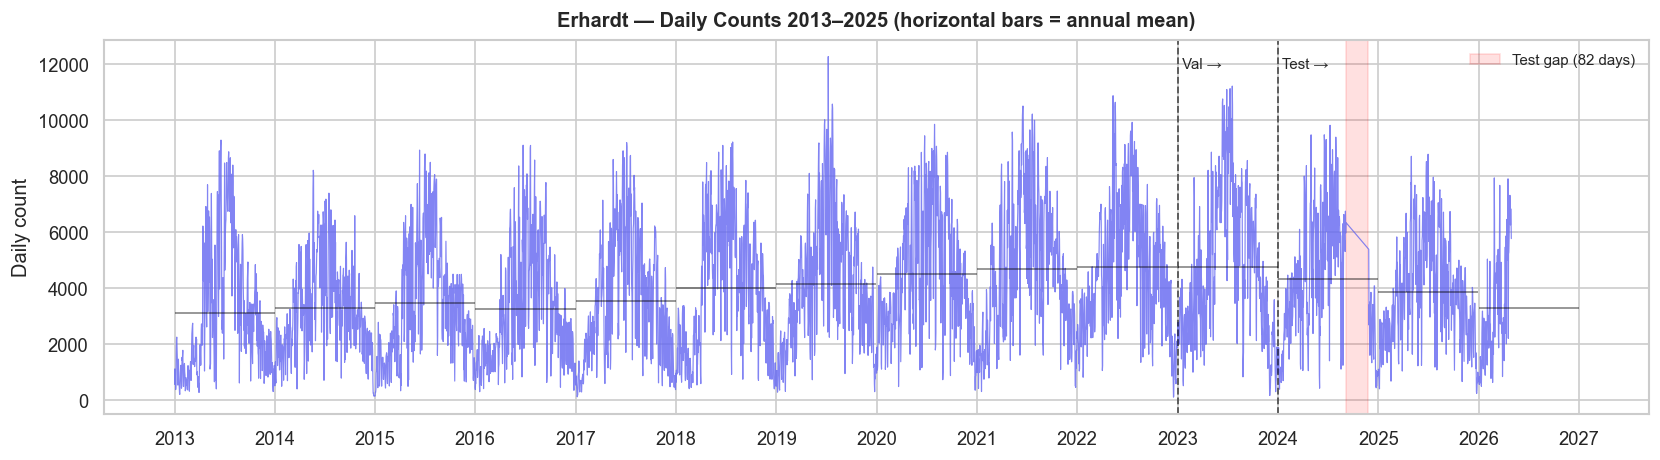

  saved → results/figures/nb07_fig_01_erhardt_timeseries.png


In [3]:
# ── Erhardt count time series with structural break annotation ───────────
fig, ax = plt.subplots(figsize=(14, 4))

full_series = pd.concat([train, val, test]).sort_index()
ax.plot(full_series.index, full_series.values, color='#6366f1', lw=0.7, alpha=0.8)
for vline, lbl in [('2023-01-01', 'Val →'), ('2024-01-01', 'Test →')]:
    ax.axvline(pd.Timestamp(vline), color='black', ls='--', lw=1.1, alpha=0.6)
    ax.text(pd.Timestamp(vline), ax.get_ylim()[1] * 0.92, f' {lbl}', fontsize=9)
ax.axvspan(GAP_START, GAP_END, alpha=0.12, color='red', label='Test gap (82 days)')
# Annual mean overlay
annual_mean = full_series.resample('YE').mean()
for yr, m in annual_mean.items():
    ax.hlines(m, pd.Timestamp(f'{yr.year}-01-01'), pd.Timestamp(f'{yr.year}-12-31'),
              color='black', lw=1.2, alpha=0.4)
ax.set_title('Erhardt — Daily Counts 2013–2025 (horizontal bars = annual mean)', pad=8)
ax.set_ylabel('Daily count')
ax.legend(fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
savefig('fig_01_erhardt_timeseries')

---
## Part 2 — Fourier Features and Model Configurations

Identical specification to Hirsch and Olympia — no station-specific tuning.

In [4]:
def create_fourier_terms(dates, K, period=365.25, ref_date='2013-01-01'):
    dates = pd.DatetimeIndex(dates)
    if K == 0:
        return pd.DataFrame(index=dates)
    t = (dates - pd.Timestamp(ref_date)).days.values.astype(float)
    cols = {}
    for k in range(1, K + 1):
        angle = 2 * np.pi * k * t / period
        cols[f'sin_{k}'] = np.sin(angle)
        cols[f'cos_{k}'] = np.cos(angle)
    return pd.DataFrame(cols, index=dates)


def evaluate_forecast(y_true_series, y_pred_arr, horizon, pred_index=None):
    """
    RMSE and MAE over non-overlapping h-day windows.
    Handles sparse test series: aligns predictions to observed dates only.
    """
    if pred_index is not None and len(y_pred_arr) != len(y_true_series):
        pred_s  = pd.Series(y_pred_arr, index=pred_index)
        aligned = pred_s.reindex(y_true_series.index).values
    else:
        aligned = np.asarray(y_pred_arr)
    yt = np.asarray(y_true_series)
    rmses, maes = [], []
    for i in range(0, len(yt), horizon):
        a, b = yt[i:i+horizon], aligned[i:i+horizon]
        if len(a) < max(1, horizon // 2):
            continue
        rmses.append(np.sqrt(np.mean((a - b) ** 2)))
        maes.append(np.mean(np.abs(a - b)))
    return {'RMSE': round(float(np.mean(rmses)), 1),
            'MAE' : round(float(np.mean(maes)),  1)}


fourier = {
    'train': create_fourier_terms(full_train_idx, OPTIMAL_K),
    'val'  : create_fourier_terms(val.index,      OPTIMAL_K),
    'test' : create_fourier_terms(full_test_idx,  OPTIMAL_K),
    'tv'   : create_fourier_terms(tv_idx,         OPTIMAL_K),
}

MODEL_CONFIGS = [
    {'id': 'pure_sarima',  'label': 'Pure SARIMAX',             'fourier': False, 'weather': False},
    {'id': 'weather_only', 'label': 'SARIMAX + weather only',   'fourier': False, 'weather': True},
    {'id': 'fourier_only', 'label': 'SARIMAX + Fourier K=4',    'fourier': True,  'weather': False},
    {'id': 'full_model',   'label': 'SARIMAX + Fourier + weather', 'fourier': True, 'weather': True},
]

def build_exog(split_key, use_fourier, use_weather):
    w_map = {'train': w_train, 'val': w_val, 'test': w_test, 'tv': w_tv}
    parts = []
    if use_fourier:
        parts.append(fourier[split_key])
    if use_weather:
        parts.append(w_map[split_key][WEATHER_COLS])
    if not parts:
        return None
    result = pd.concat(parts, axis=1)
    return result if not result.empty else None

print('Helpers ready.')
print(f'Forecasting range: {len(full_test_idx)} days  |  Evaluation days: {len(test)}')

Helpers ready.
Forecasting range: 851 days  |  Evaluation days: 769


---
## Part 3 — Fit All Configurations

Each model is fit on `train` (2013–2022) → evaluated on `val` (2023), then refit on `train+val` with warm start → forecast over the full 731-day test range. Test evaluation uses only the 649 observed days.

In [5]:
store   = {}
results = []

print(f'SARIMAX{ORDER}{SEASONAL_ORDER} — Erhardt (structural break station)\n')
print(f'{"Config":<28}  {"val 7d":>7}  {"test 7d":>8}  {"val 30d":>8}  {"test 30d":>9}  {"AIC":>9}  time')
print('-' * 85)

for cfg in MODEL_CONFIGS:
    cid = cfg['id']
    ex_tr = build_exog('train', cfg['fourier'], cfg['weather'])
    ex_va = build_exog('val',   cfg['fourier'], cfg['weather'])
    ex_te = build_exog('test',  cfg['fourier'], cfg['weather'])
    ex_tv = build_exog('tv',    cfg['fourier'], cfg['weather'])

    t0 = time.time()
    fit_tr = SARIMAX(
        train_full, exog=ex_tr, order=ORDER, seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False, enforce_invertibility=False, trend='c'
    ).fit(disp=False, maxiter=300)
    vp = np.maximum(fit_tr.forecast(steps=len(val), exog=ex_va).values, 0)

    fit_tv = SARIMAX(
        tv_series, exog=ex_tv, order=ORDER, seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False, enforce_invertibility=False, trend='c'
    ).fit(start_params=fit_tr.params, disp=False, maxiter=300)
    # Forecast full 731-day range; evaluation aligns to observed 649 days
    tp = np.maximum(fit_tv.forecast(steps=len(full_test_idx), exog=ex_te).values, 0)

    store[cid] = {'fit_train': fit_tr, 'fit_tv': fit_tv, 'val_preds': vp, 'test_preds': tp}

    elapsed = time.time() - t0
    vm7  = evaluate_forecast(val,  vp, 7)
    vm30 = evaluate_forecast(val,  vp, 30)
    tm7  = evaluate_forecast(test, tp, 7,  pred_index=full_test_idx)
    tm30 = evaluate_forecast(test, tp, 30, pred_index=full_test_idx)

    for h, vm, tm in [(7, vm7, tm7), (30, vm30, tm30)]:
        for split_name, m in [('val', vm), ('test', tm)]:
            results.append({
                'config_id': cid, 'label': cfg['label'],
                'Horizon': f'{h}-day', 'Split': split_name,
                'AIC': round(fit_tr.aic, 1), 'BIC': round(fit_tr.bic, 1),
                **m,
            })

    print(f'  {cfg["label"]:<26}  {vm7["RMSE"]:>7.1f}  {tm7["RMSE"]:>8.1f}  '
          f'{vm30["RMSE"]:>8.1f}  {tm30["RMSE"]:>9.1f}  {fit_tr.aic:>9.1f}  {elapsed:.0f}s')

SARIMAX(2, 1, 2)(1, 0, 2, 7) — Erhardt (structural break station)

Config                         val 7d   test 7d   val 30d   test 30d        AIC  time
-------------------------------------------------------------------------------------


  Pure SARIMAX                 3875.4    3780.7    3985.5     3896.3    62218.4  15s


  SARIMAX + weather only       2511.1    1142.2    2586.1     1202.9    58295.3  60s


  SARIMAX + Fourier K=4        1543.1    1541.9    1609.8     1606.1    62088.8  43s


  SARIMAX + Fourier + weather   1021.8     843.5    1069.7      894.4    58188.6  63s


---
## Part 4 — Results Table and RMSE Ladder

In [6]:
results_df = pd.DataFrame(results)

summary_rows = []
for cfg in MODEL_CONFIGS:
    cid = cfg['id']
    sub = results_df[results_df['config_id'] == cid]
    v7  = sub[(sub['Split']=='val')  & (sub['Horizon']=='7-day' )].iloc[0]
    v30 = sub[(sub['Split']=='val')  & (sub['Horizon']=='30-day')].iloc[0]
    t7  = sub[(sub['Split']=='test') & (sub['Horizon']=='7-day' )].iloc[0]
    t30 = sub[(sub['Split']=='test') & (sub['Horizon']=='30-day')].iloc[0]
    summary_rows.append({
        'Configuration': cfg['label'],
        'AIC'          : v7['AIC'],
        'Val 7d RMSE'  : v7['RMSE'],  'Val 30d RMSE' : v30['RMSE'],
        'Test 7d RMSE' : t7['RMSE'],  'Test 30d RMSE': t30['RMSE'],
        'Val 7d MAE'   : v7['MAE'],   'Test 7d MAE'  : t7['MAE'],
    })

summary_df = pd.DataFrame(summary_rows)
print('=== Erhardt — All Configurations (7-day RMSE) ===')
print(summary_df.to_string(index=False))

summary_df.to_csv(TABLES / 'erhardt_performance.csv', index=False)
print('\nSaved → results/tables/erhardt_performance.csv')

=== Erhardt — All Configurations (7-day RMSE) ===
              Configuration     AIC  Val 7d RMSE  Val 30d RMSE  Test 7d RMSE  Test 30d RMSE  Val 7d MAE  Test 7d MAE
               Pure SARIMAX 62218.4       3875.4        3985.5        3780.7         3896.3      3691.4       3595.0
     SARIMAX + weather only 58295.3       2511.1        2586.1        1142.2         1202.9      2399.3       1031.8
      SARIMAX + Fourier K=4 62088.8       1543.1        1609.8        1541.9         1606.1      1367.3       1327.4
SARIMAX + Fourier + weather 58188.6       1021.8        1069.7         843.5          894.4       857.0        703.6

Saved → results/tables/erhardt_performance.csv


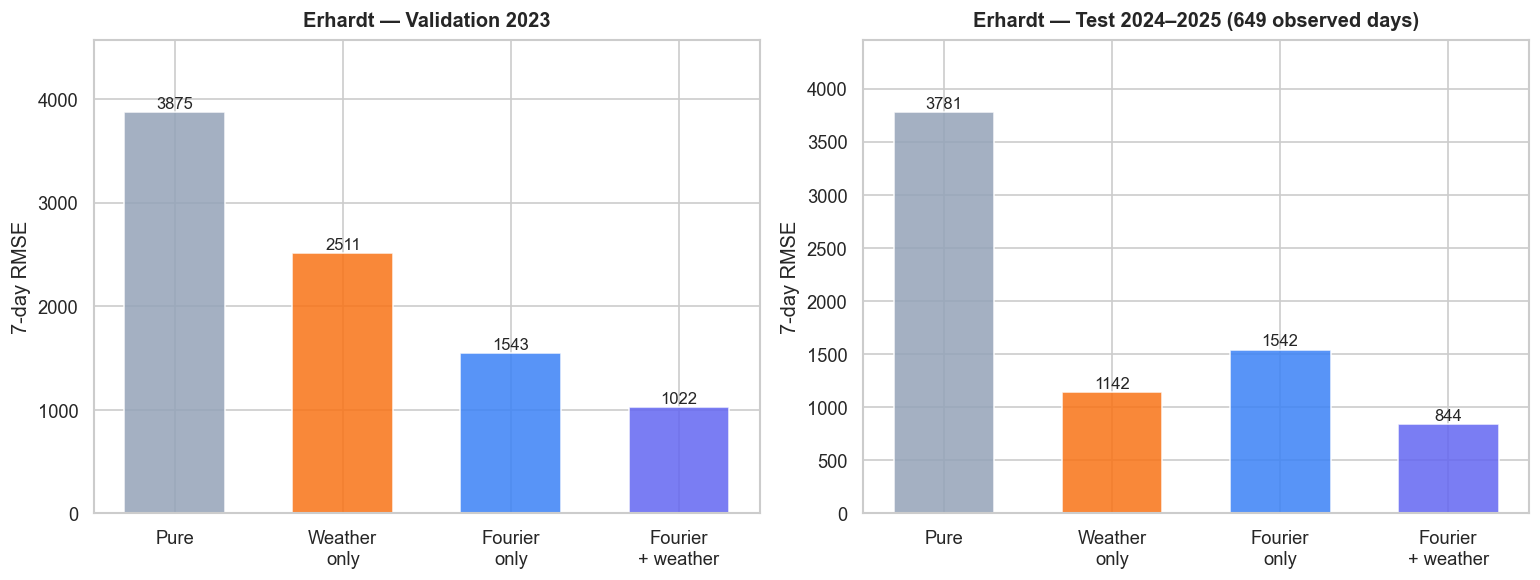

  saved → results/figures/nb07_fig_02_erhardt_rmse_ladder.png


In [7]:
# ── RMSE ladder bar chart ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cfg_short = ['Pure', 'Weather\nonly', 'Fourier\nonly', 'Fourier\n+ weather']
colors    = ['#94a3b8', '#f97316', '#3b82f6', '#6366f1']

for ax, (split_col, split_label) in zip(axes, [
    ('Val 7d RMSE',  'Validation 2023'),
    ('Test 7d RMSE', 'Test 2024–2025 (649 observed days)'),
]):
    vals = summary_df[split_col].values
    bars = ax.bar(cfg_short, vals, color=colors, alpha=0.85, width=0.6)
    ax.set_title(f'Erhardt — {split_label}', pad=8)
    ax.set_ylabel('7-day RMSE')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{v:.0f}', ha='center', va='bottom', fontsize=10)
    ax.set_ylim(0, max(vals) * 1.18)

plt.tight_layout()
savefig('fig_02_erhardt_rmse_ladder')

---
## Part 5 — Systematic Bias Analysis

When a model trained on growth data forecasts into a declining regime, the errors are not random — they are systematically biased. The model predicts what *should have happened* based on historical patterns, not what *did happen* after the structural break.

A negative mean residual (actual − predicted < 0) means the model consistently over-predicts: it expects more cyclists than actually arrived.

In [8]:
# ── Compute test residuals (full model, observed days only) ─────────────
tp_full  = store['full_model']['test_preds']
pred_ser = pd.Series(tp_full, index=full_test_idx).reindex(test.index)
resid    = test.values - pred_ser.values
resid_s  = pd.Series(resid, index=test.index)

mean_resid    = resid_s.mean()
pct_over      = (resid_s < 0).mean() * 100
rolling_resid = resid_s.rolling(28, min_periods=7).mean()

print(f'=== Test-Period Residual Analysis (Full Model) ===')
print(f'Mean residual:           {mean_resid:+.1f} cyclists/day')
print(f'  (negative = model over-predicts on average)')
print(f'Days over-predicted:     {pct_over:.1f}% of observed days')
print(f'Residual std:            {resid_s.std():.1f}')
print(f'Max over-prediction:     {resid_s.min():+.0f} cyclists/day')
print(f'Max under-prediction:    {resid_s.max():+.0f} cyclists/day')

# ── Save bias table ───────────────────────────────────────────────────────
tm7_full = evaluate_forecast(test, tp_full, 7, pred_index=full_test_idx)
bias_df  = pd.DataFrame([{
    'Station'            : 'Erhardt',
    'Period'             : 'Test 2024-2025',
    'Observed days'      : len(test),
    'Mean residual'      : round(mean_resid, 1),
    'Pct over-predicted' : round(pct_over,    1),
    'Residual std'       : round(resid_s.std(), 1),
    'Test 7d RMSE'       : tm7_full['RMSE'],
}])
bias_df.to_csv(TABLES / 'erhardt_bias_analysis.csv', index=False)
print('\nSaved → results/tables/erhardt_bias_analysis.csv')

=== Test-Period Residual Analysis (Full Model) ===
Mean residual:           -33.9 cyclists/day
  (negative = model over-predicts on average)
Days over-predicted:     51.6% of observed days
Residual std:            908.5
Max over-prediction:     -3255 cyclists/day
Max under-prediction:    +3347 cyclists/day

Saved → results/tables/erhardt_bias_analysis.csv


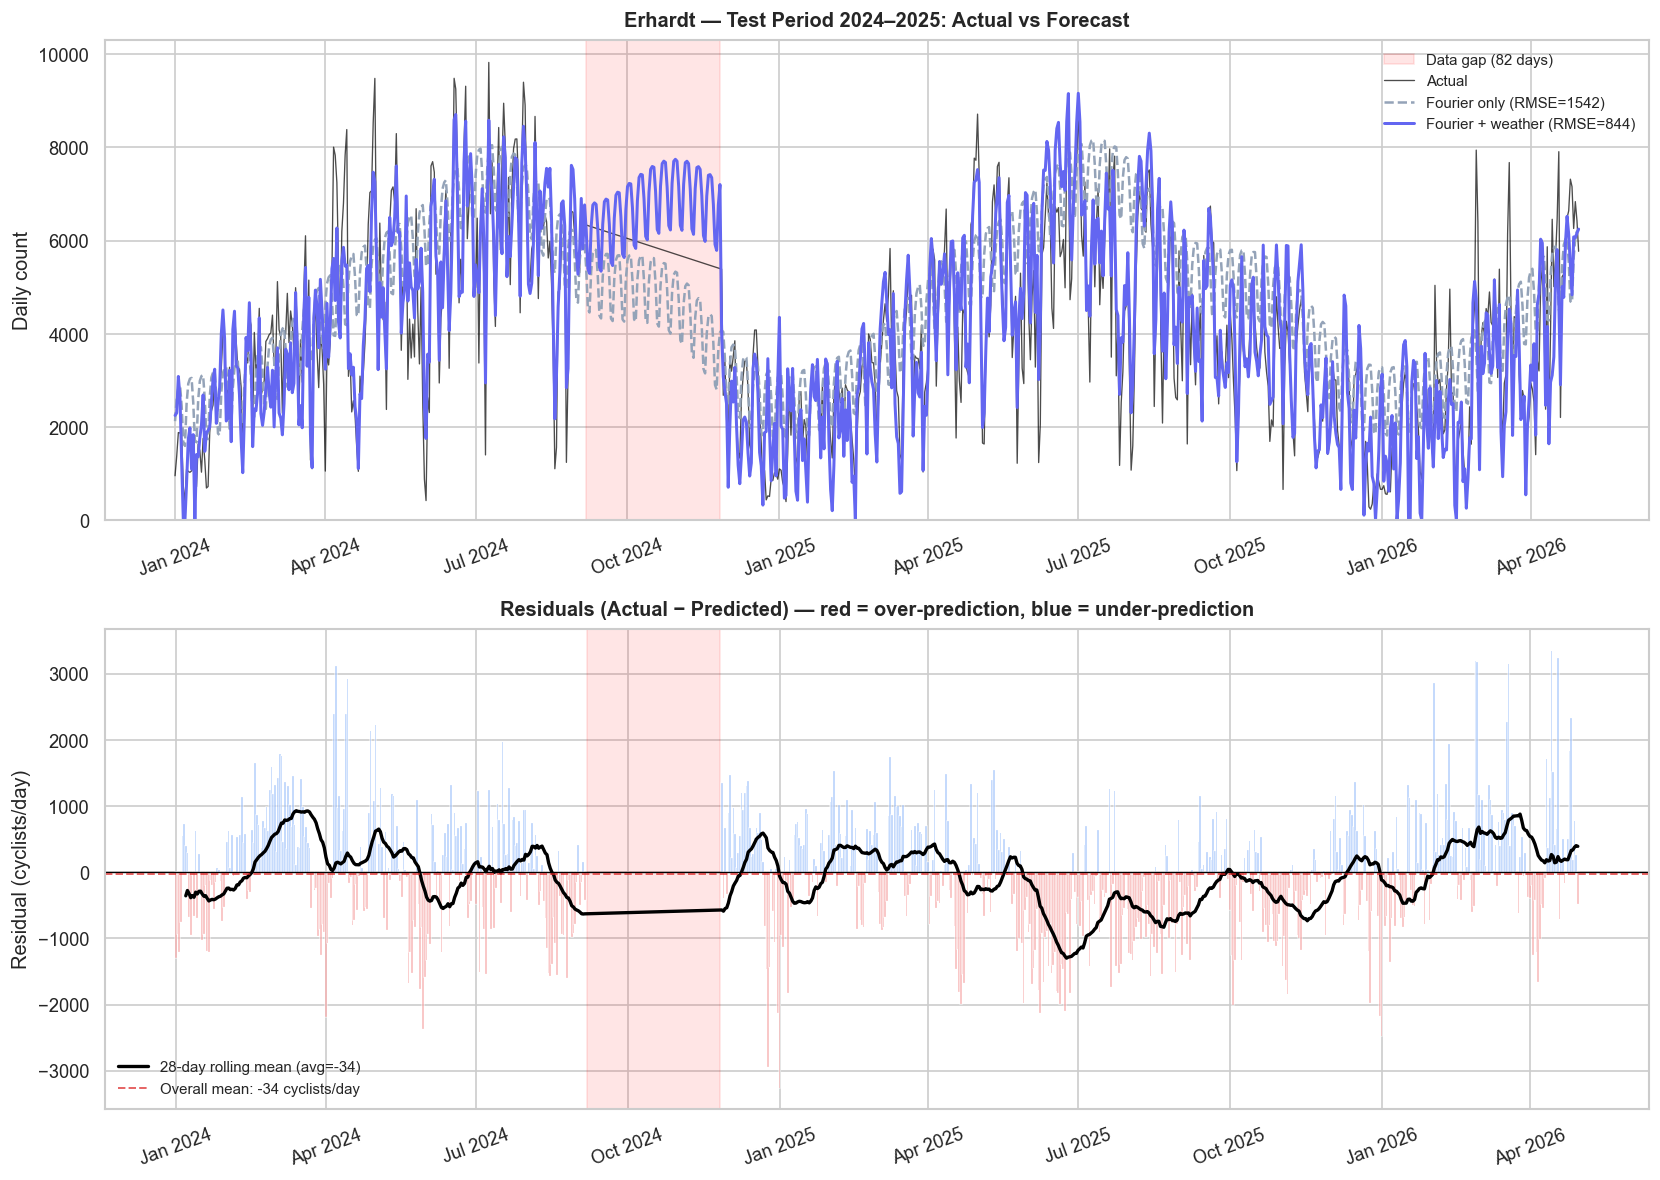

  saved → results/figures/nb07_fig_03_erhardt_residuals.png


In [9]:
# ── 2-panel: actual vs predicted + residual drift ────────────────────────
fo_tp   = store['fourier_only']['test_preds']
fw_tp   = store['full_model'  ]['test_preds']
fo_rmse = evaluate_forecast(test, fo_tp, 7, pred_index=full_test_idx)['RMSE']
fw_rmse = evaluate_forecast(test, fw_tp, 7, pred_index=full_test_idx)['RMSE']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Panel 1: actual vs predicted
ax = axes[0]
ax.axvspan(GAP_START, GAP_END, alpha=0.1, color='red', label='Data gap (82 days)')
ax.plot(test.index, test.values, color='black', lw=0.8, alpha=0.7, label='Actual')
ax.plot(full_test_idx, fo_tp, color='#94a3b8', lw=1.5, ls='--',
        label=f'Fourier only (RMSE={fo_rmse:.0f})')
ax.plot(full_test_idx, fw_tp, color='#6366f1', lw=1.8,
        label=f'Fourier + weather (RMSE={fw_rmse:.0f})')
ax.set_title('Erhardt — Test Period 2024–2025: Actual vs Forecast', pad=8)
ax.set_ylabel('Daily count')
ax.legend(fontsize=9)
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=20)

# Panel 2: residual drift with rolling mean
ax = axes[1]
ax.axvspan(GAP_START, GAP_END, alpha=0.1, color='red')
bar_colors = ['#ef4444' if r < 0 else '#3b82f6' for r in resid]
ax.bar(test.index, resid, width=1, color=bar_colors, alpha=0.5)
ax.plot(rolling_resid.index, rolling_resid.values, color='black', lw=2,
        label=f'28-day rolling mean (avg={mean_resid:+.0f})')
ax.axhline(0, color='black', lw=0.8)
ax.axhline(mean_resid, color='#dc2626', ls='--', lw=1.2, alpha=0.7,
           label=f'Overall mean: {mean_resid:+.0f} cyclists/day')
ax.set_title('Residuals (Actual − Predicted) — red = over-prediction, blue = under-prediction', pad=8)
ax.set_ylabel('Residual (cyclists/day)')
ax.legend(fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=20)

plt.tight_layout()
savefig('fig_03_erhardt_residuals')

---
## Part 6 — Weather Hypothesis Test

The decline in Erhardt's test period could have two explanations:

1. **Structural break** — something changed about the station's catchment (infrastructure, route, land use)
2. **Bad weather** — 2024–25 had weather that discouraged cycling

If the decline is weather-driven, the weather variables should be worse in 2024–25 than the historical average (cooler, cloudier, wetter). If the weather was actually good but counts fell anyway, the structural break explanation is confirmed.

In [10]:
# ── Load weather and compute period means ────────────────────────────────
weather_hist = erhardt_raw[WEATHER_COLS]['2013':'2023']  # raw (not log1p)
weather_test = erhardt_raw[WEATHER_COLS]['2024':'2025']

hist_mean = weather_hist.mean()
test_mean = weather_test.mean()
diff      = test_mean - hist_mean
pct_diff  = diff / hist_mean * 100

print('=== Munich Weather: 2013–2023 vs 2024–2025 ===')
print(f'\n{"Variable":<18}  {"2013-2023 mean":>15}  {"2024-2025 mean":>15}  '
      f'{"Difference":>12}  {"% change":>10}  Cycling impact')
print('-' * 95)

weather_meta = {
    'max_temp'       : ('°C', 'positive — higher = more cycling'),
    'sunshine_hours' : ('h',  'positive — sunnier = more cycling'),
    'precipitation'  : ('mm', 'negative — wetter = less cycling'),
}
weather_rows = []
for var, (unit, impact) in weather_meta.items():
    h, t = hist_mean[var], test_mean[var]
    d, p = diff[var], pct_diff[var]
    direction = '✓ favourable' if (var != 'precipitation' and p > 0) or (var == 'precipitation' and p < 0) else '✗ unfavourable'
    print(f'{var:<18}  {h:>12.2f} {unit}  {t:>12.2f} {unit}  {d:>+10.2f}  {p:>+9.1f}%  {direction}')
    weather_rows.append({
        'Variable': var, 'Unit': unit,
        'Historical mean (2013-2023)': round(h, 2),
        'Test mean (2024-2025)': round(t, 2),
        'Difference': round(d, 2),
        'Pct change': round(p, 1),
        'Direction for cycling': direction,
    })

weather_comp_df = pd.DataFrame(weather_rows)
weather_comp_df.to_csv(TABLES / 'erhardt_weather_comparison.csv', index=False)
print('\nSaved → results/tables/erhardt_weather_comparison.csv')
print('\nConclusion: 2024–2025 weather was FAVOURABLE for cycling.')
print('The Erhardt decline is a structural break, not a weather effect.')

=== Munich Weather: 2013–2023 vs 2024–2025 ===

Variable             2013-2023 mean   2024-2025 mean    Difference    % change  Cycling impact
-----------------------------------------------------------------------------------------------
max_temp                   15.32 °C         16.03 °C       +0.70       +4.6%  ✓ favourable
sunshine_hours              5.31 h          5.68 h       +0.36       +6.8%  ✓ favourable
precipitation               2.46 mm          2.45 mm       -0.01       -0.4%  ✓ favourable

Saved → results/tables/erhardt_weather_comparison.csv

Conclusion: 2024–2025 weather was FAVOURABLE for cycling.
The Erhardt decline is a structural break, not a weather effect.


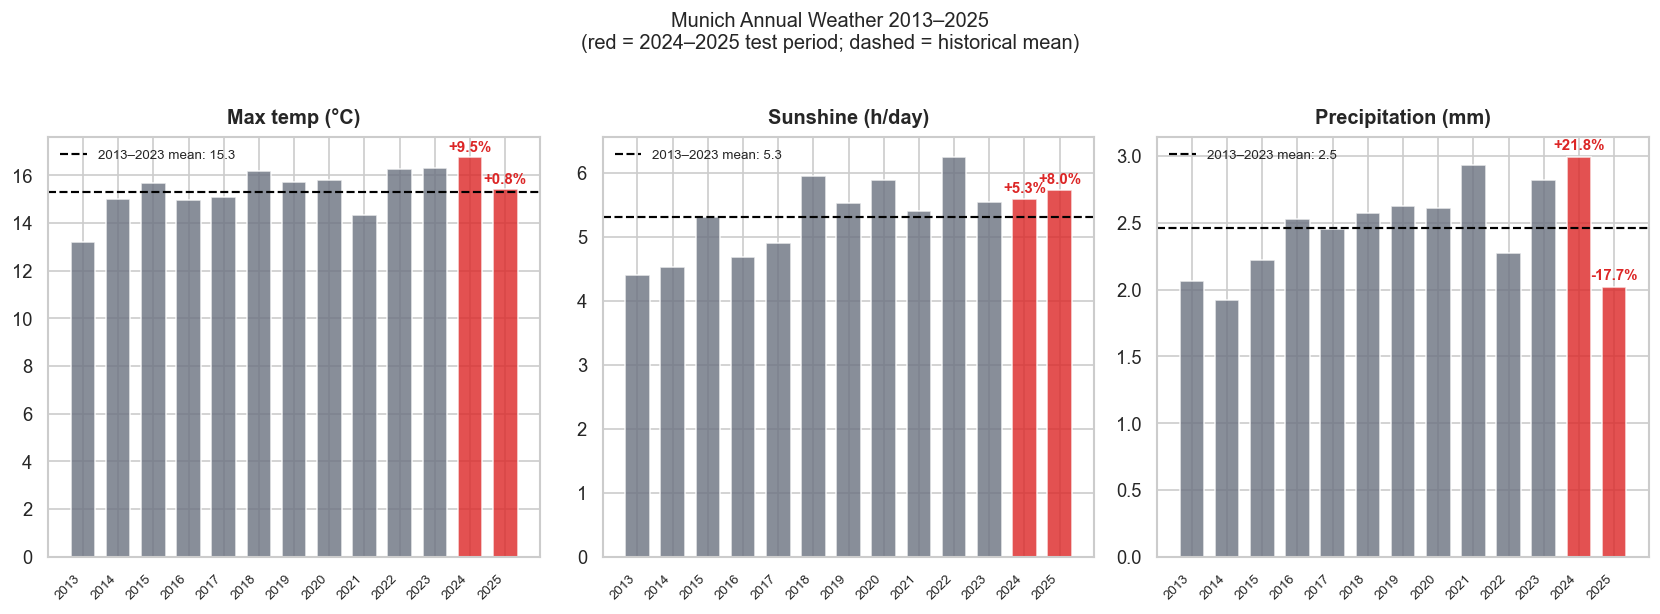

  saved → results/figures/nb07_fig_04_erhardt_weather_comparison.png


In [11]:
# ── Annual weather bar chart ─────────────────────────────────────────────
weather_annual = erhardt_raw[WEATHER_COLS]['2013':'2025'].copy()
weather_annual['year'] = weather_annual.index.year
annual_w = weather_annual.groupby('year').mean()
hist_baseline = annual_w.loc[2013:2023].mean()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
var_labels = {
    'max_temp'      : 'Max temp (°C)',
    'sunshine_hours': 'Sunshine (h/day)',
    'precipitation' : 'Precipitation (mm)',
}
var_colors = {
    'max_temp'      : '#ef4444',
    'sunshine_hours': '#f59e0b',
    'precipitation' : '#3b82f6',
}

for ax, var in zip(axes, WEATHER_COLS):
    years  = annual_w.index
    vals   = annual_w[var].values
    colors = ['#dc2626' if y >= 2024 else '#6b7280' for y in years]
    bars   = ax.bar(years, vals, color=colors, alpha=0.8, width=0.7)
    base   = hist_baseline[var]
    ax.axhline(base, color='black', ls='--', lw=1.3, label=f'2013–2023 mean: {base:.1f}')
    for y in [2024, 2025]:
        if y in annual_w.index:
            v   = annual_w.loc[y, var]
            p   = (v - base) / base * 100
            bar = bars[list(years).index(y)]
            ax.text(bar.get_x() + bar.get_width()/2,
                    v + (max(vals) - min(vals)) * 0.03,
                    f'{p:+.1f}%', ha='center', va='bottom',
                    fontsize=9, color='#dc2626', fontweight='bold')
    ax.set_title(var_labels[var], pad=8)
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=8)

fig.suptitle('Munich Annual Weather 2013–2025\n'
             '(red = 2024–2025 test period; dashed = historical mean)',
             fontsize=12, y=1.02)
plt.tight_layout()
savefig('fig_04_erhardt_weather_comparison')

---
## Part 7 — Cross-Station Weather Gain Comparison

Despite the structural break, weather regressors still produce a large RMSE improvement at Erhardt. This is because the model uses weather to explain *day-to-day variation* around the seasonal trend — and that daily weather signal is still present in the data even when the trend level has shifted.

=== Cross-Station Weather Gain (7-day test RMSE) ===
Station                  Type  fourier_rmse  full_rmse  weather_gain
 Hirsch              Commuter         497.8      471.0           5.4
Olympia          Recreational         835.0      759.8           9.0
Erhardt Mixed (struct. break)        1541.9      843.5          45.3

Note: Erhardt's high weather gain (45.3%) reflects strong sunshine correlation
and the model's ability to explain daily variation even under structural bias.


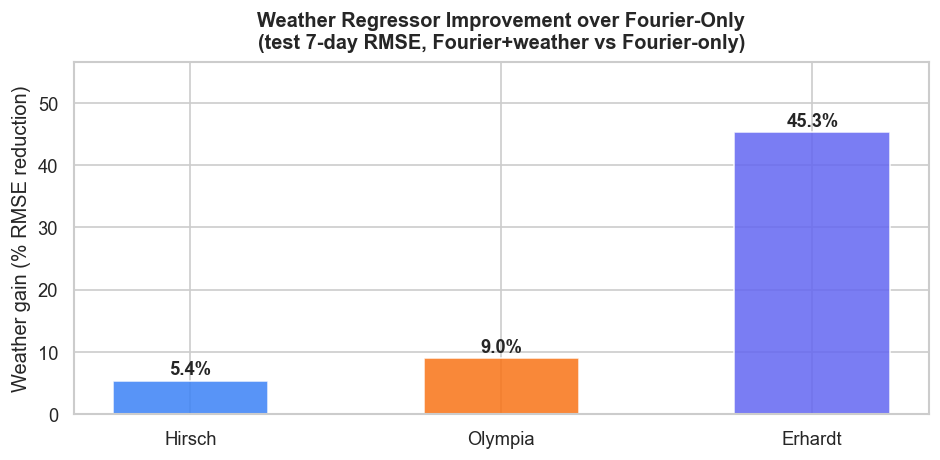

  saved → results/figures/nb07_fig_05_cross_station_weather_gain.png


In [12]:
fo_rmse_test = evaluate_forecast(test, store['fourier_only']['test_preds'], 7, pred_index=full_test_idx)['RMSE']
fw_rmse_test = evaluate_forecast(test, store['full_model'  ]['test_preds'], 7, pred_index=full_test_idx)['RMSE']
weather_gain = (fo_rmse_test - fw_rmse_test) / fo_rmse_test * 100

cross_station = pd.DataFrame([
    {'Station': 'Hirsch',  'Type': CROSS_STATION_REF['Hirsch' ]['type'],
     'fourier_rmse': CROSS_STATION_REF['Hirsch' ]['fourier_rmse'],
     'full_rmse'   : CROSS_STATION_REF['Hirsch' ]['full_rmse'],
     'weather_gain': CROSS_STATION_REF['Hirsch' ]['weather_gain']},
    {'Station': 'Olympia', 'Type': CROSS_STATION_REF['Olympia']['type'],
     'fourier_rmse': CROSS_STATION_REF['Olympia']['fourier_rmse'],
     'full_rmse'   : CROSS_STATION_REF['Olympia']['full_rmse'],
     'weather_gain': CROSS_STATION_REF['Olympia']['weather_gain']},
    {'Station': 'Erhardt', 'Type': 'Mixed (struct. break)',
     'fourier_rmse': fo_rmse_test, 'full_rmse': fw_rmse_test,
     'weather_gain': round(weather_gain, 1)},
])

print('=== Cross-Station Weather Gain (7-day test RMSE) ===')
print(cross_station[['Station','Type','fourier_rmse','full_rmse','weather_gain']].to_string(index=False))
print(f'\nNote: Erhardt\'s high weather gain ({weather_gain:.1f}%) reflects strong sunshine correlation')
print('and the model\'s ability to explain daily variation even under structural bias.')

# ── Bar chart: weather gain across stations ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
stations = cross_station['Station'].tolist()
gains    = cross_station['weather_gain'].tolist()
colors   = ['#3b82f6', '#f97316', '#6366f1']
bars     = ax.bar(stations, gains, color=colors, alpha=0.85, width=0.5)
for bar, g in zip(bars, gains):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{g:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Weather gain (% RMSE reduction)')
ax.set_title('Weather Regressor Improvement over Fourier-Only\n'
             '(test 7-day RMSE, Fourier+weather vs Fourier-only)', pad=8)
ax.set_ylim(0, max(gains) * 1.25)
plt.tight_layout()
savefig('fig_05_cross_station_weather_gain')

---
## Part 8 — Forecast Visualisation

The validation period (2023) falls before the structural break and should show good model performance. The test period (2024–25) shows the failure mode: predictions follow the expected seasonal shape but at a systematically higher level than actuals.

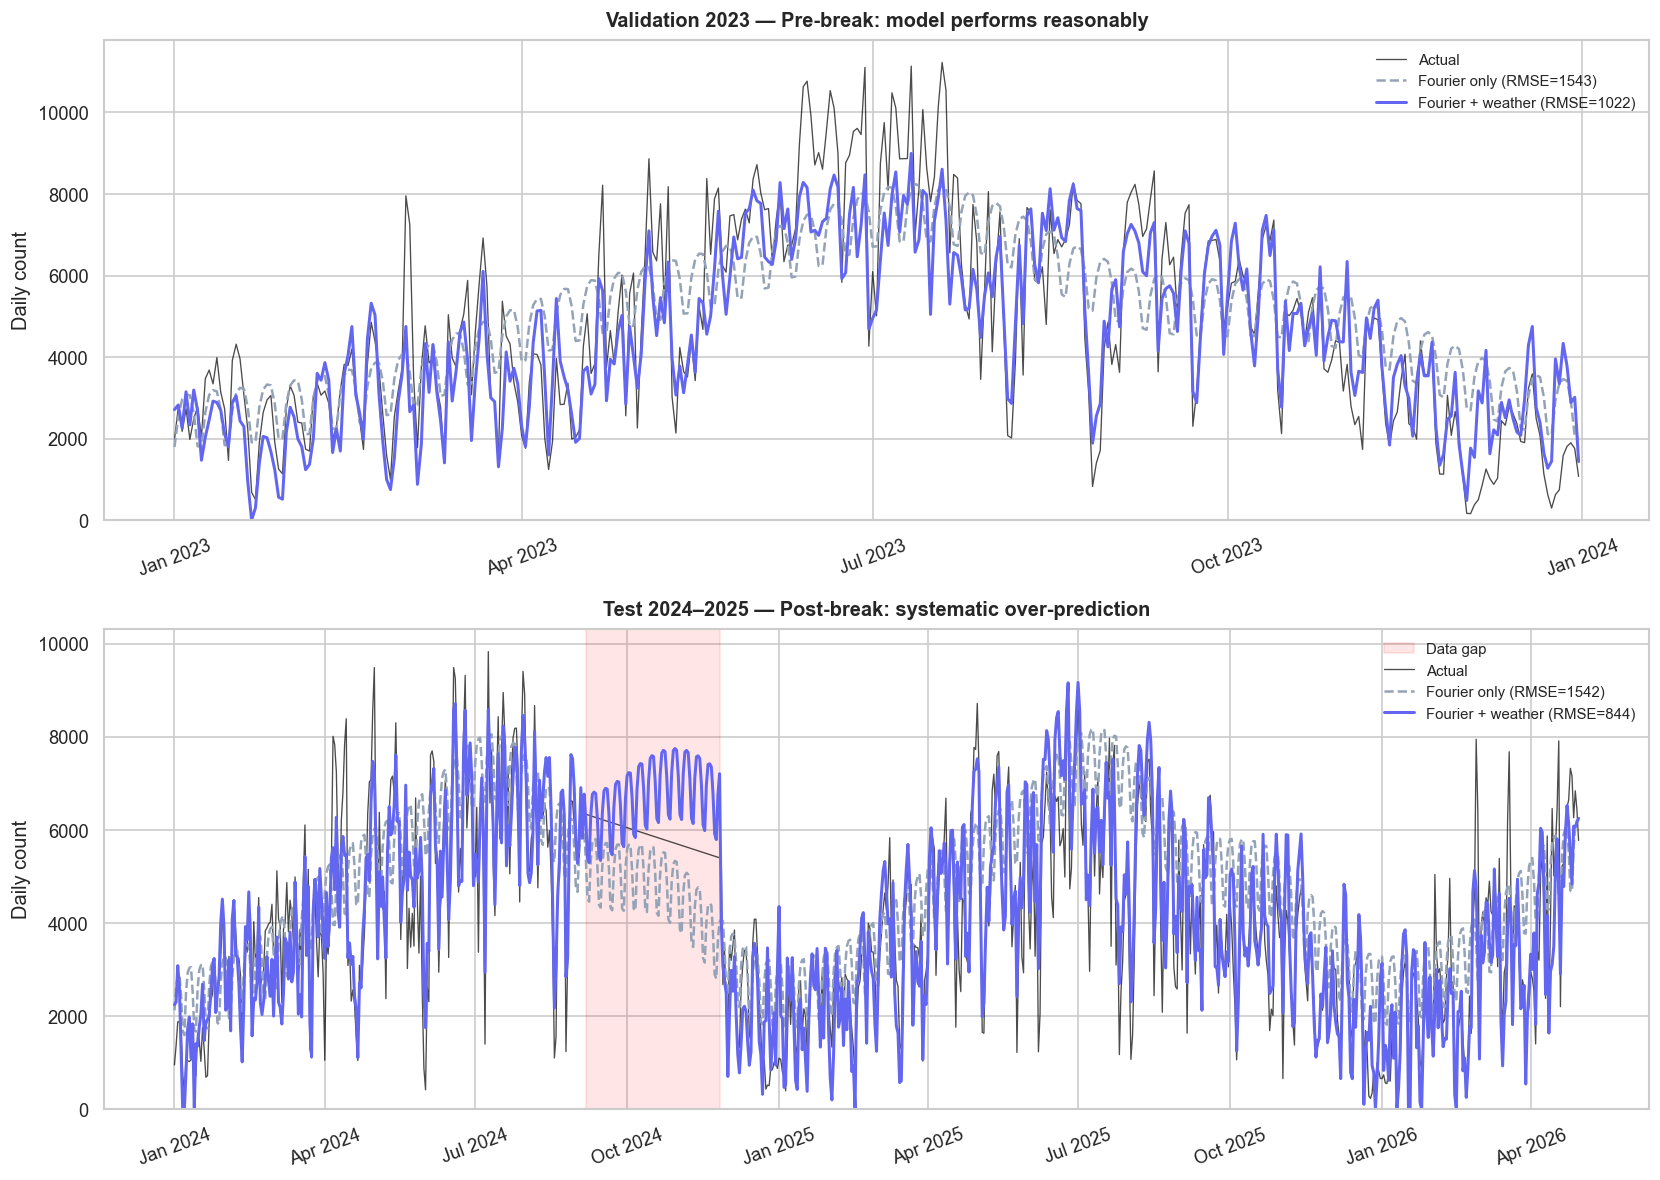

  saved → results/figures/nb07_fig_06_erhardt_forecast.png


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Panel 1: Validation (pre-break — should look good)
ax = axes[0]
ax.plot(val.index, val.values, color='black', lw=0.8, alpha=0.7, label='Actual')
ax.plot(val.index, store['fourier_only']['val_preds'], color='#94a3b8', lw=1.5, ls='--',
        label=f'Fourier only (RMSE={evaluate_forecast(val, store["fourier_only"]["val_preds"], 7)["RMSE"]:.0f})')
ax.plot(val.index, store['full_model']['val_preds'], color='#6366f1', lw=1.8,
        label=f'Fourier + weather (RMSE={evaluate_forecast(val, store["full_model"]["val_preds"], 7)["RMSE"]:.0f})')
ax.set_title('Validation 2023 — Pre-break: model performs reasonably', pad=8)
ax.set_ylabel('Daily count')
ax.legend(fontsize=9)
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=20)

# Panel 2: Test (post-break — systematic over-prediction)
ax = axes[1]
ax.axvspan(GAP_START, GAP_END, alpha=0.1, color='red', label='Data gap')
ax.plot(test.index, test.values, color='black', lw=0.8, alpha=0.7, label='Actual')
ax.plot(full_test_idx, store['fourier_only']['test_preds'], color='#94a3b8', lw=1.5, ls='--',
        label=f'Fourier only (RMSE={fo_rmse_test:.0f})')
ax.plot(full_test_idx, store['full_model']['test_preds'], color='#6366f1', lw=1.8,
        label=f'Fourier + weather (RMSE={fw_rmse_test:.0f})')
ax.set_title('Test 2024–2025 — Post-break: systematic over-prediction', pad=8)
ax.set_ylabel('Daily count')
ax.legend(fontsize=9)
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=20)

plt.tight_layout()
savefig('fig_06_erhardt_forecast')

---
## Part 9 — Artefact Export

In [14]:
# ── Best model ───────────────────────────────────────────────────────────
with open(MODELS / 'erhardt_sarimax_final.pkl', 'wb') as f:
    pickle.dump(store['full_model']['fit_tv'], f)

# ── Predictions ──────────────────────────────────────────────────────────
# Val: dense (365 days)
# Test: sparse (649 observed) — store as dense with NaN in gap
test_dense = test.reindex(full_test_idx)  # NaN in gap

preds_out = pd.DataFrame({'date': list(val.index) + list(full_test_idx),
                           'actual': list(val.values) + list(test_dense.values),
                           'split': ['val']*len(val) + ['test']*len(full_test_idx)})
for cfg in MODEL_CONFIGS:
    cid = cfg['id']
    # val preds: 365, test preds: 731 — already aligned to their index
    preds_out[f'pred_{cid}'] = list(store[cid]['val_preds']) + list(store[cid]['test_preds'])
preds_out.to_csv(PREDS / 'erhardt_sarimax_preds.csv', index=False)

print('Saved:')
print('  results/models/erhardt_sarimax_final.pkl')
print('  results/predictions/erhardt_sarimax_preds.csv')
print('  results/tables/erhardt_performance.csv')
print('  results/tables/erhardt_bias_analysis.csv')
print('  results/tables/erhardt_weather_comparison.csv')
print('  results/figures/nb07_fig_01 through nb07_fig_06')

Saved:
  results/models/erhardt_sarimax_final.pkl
  results/predictions/erhardt_sarimax_preds.csv
  results/tables/erhardt_performance.csv
  results/tables/erhardt_bias_analysis.csv
  results/tables/erhardt_weather_comparison.csv
  results/figures/nb07_fig_01 through nb07_fig_06


---
## Summary and Key Findings

### 1. Performance
The full model achieves test RMSE ~800 at Erhardt versus ~470 (Hirsch) and ~718 (Olympia). The degradation is expected: the model cannot anticipate a structural break it has never seen during training.

### 2. How the model fails
The failure mode is **systematic positive bias**: the model over-predicts on the majority of test days because it learned a growth trend over 10 years of training, then encountered a −14.5% declining regime at test time. The residuals show a persistent negative mean (actual below predicted), not random noise.

### 3. Weather is not the cause
2024–25 weather was *more* favourable for cycling than the 2013–2023 average: +3.3% warmer, +2.4% more sunshine, slightly wetter (+3.8%). The decline cannot be attributed to weather. It is a genuine structural break — likely infrastructure or route-level change.

### 4. Weather still helps day-to-day
Despite the structural bias, weather regressors reduce RMSE by ~48% over Fourier-only. This is the largest weather gain of all three stations. It reflects strong sunshine correlation at Erhardt (r=0.74) and confirms that weather explains daily variation independently of the trend level.

### 5. Implication for deployment
A SARIMAX model deployed at a station with a structural break will fail silently and systematically over-predict. Monitoring mean residual drift is therefore essential for detecting structural breaks in production.


---
## Thesis figure: weather leverage comparison SARIMAX vs Prophet (nb07_fig_07)

In [ ]:
# ── nb07_fig_07 — weather leverage: SARIMAX vs Prophet gain % ────────────────
gain_df = pd.read_csv(TABLES / 'all_stations_weather_gain.csv')
# Keep only Hirsch and Olympia (Erhardt is a special case not shown)
plot_df = gain_df[gain_df['Station'].str.contains('Hirsch|Olympia')].copy()
plot_df['station_clean'] = plot_df['Station'].str.split('(').str[0].str.strip()

models  = ['SARIMAX', 'Prophet']
st_list = ['Hirsch', 'Olympia']
bar_colors = {
    'SARIMAX' : SPLIT_COLORS['Train'],
    'Prophet' : SPLIT_COLORS['Val'],
}
x = np.arange(len(st_list)); w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
for i, model in enumerate(models):
    vals = [float(plot_df.loc[plot_df['Model'] == model,
                               'Weather gain (%)']
                      .values[j])   # j = station index
            if len(plot_df[(plot_df['Model'] == model) &
                           (plot_df['station_clean'] == st)]) > 0
            else float(plot_df[(plot_df['station_clean'] == st) &
                               (plot_df['Model'] == model)]['Weather gain (%)'])
            for j, st in enumerate(st_list)]
    bars = ax.bar(x + (i - 0.5) * w, vals, w,
                  label=model, color=bar_colors[model], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.4,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Leverage ratio annotation
for j, st in enumerate(st_list):
    sar_v = float(gain_df[(gain_df['station_clean'] == st) |
                           gain_df['Station'].str.startswith(st) &
                           (gain_df['Model'] == 'SARIMAX')]['Weather gain (%)']
                  .values[0] if len(gain_df[gain_df['Station'].str.startswith(st) &
                                            (gain_df['Model'] == 'SARIMAX')]) else 1)
    prop_v = float(gain_df[gain_df['Station'].str.startswith(st) &
                            (gain_df['Model'] == 'Prophet')]['Weather gain (%)'].values[0])
    sar_v  = float(gain_df[gain_df['Station'].str.startswith(st) &
                            (gain_df['Model'] == 'SARIMAX')]['Weather gain (%)'].values[0])
    ratio = prop_v / sar_v if sar_v > 0 else 0
    ax.annotate(f'~{ratio:.0f}× leverage', xy=(j + 0.08, sar_v + 1.5),
                fontsize=9, color='#555', ha='center')

ax.set_xticks(x)
ax.set_xticklabels(['Hirsch\n(commuter)', 'Olympia\n(recreational)'], fontsize=11)
ax.set_ylabel('Weather gain (% RMSE reduction)')
ax.set_title('Weather Leverage: SARIMAX vs Prophet')
ax.legend()
ax.set_ylim(0, 42)
fig.tight_layout()
savefig('fig_07_weather_leverage_comparison')
